# LLM Vision OCR Benchmark on Indonesian Blackboard/Whiteboard Menus

Compares **OpenAI, Claude (Anthropic), xAI (Grok), and DeepSeek** on an **OCR / handwritten-text
transcription** task using the `Blackboard/` image dataset (Indonesian food-stall menu photos with
LabelMe ground-truth text regions).

**Task:** given a menu-board photo, transcribe all visible text. We then score the transcription
against the ground truth.

**Metrics**
| Category | Metrics |
|---|---|
| **Quality** | CER (character error rate), WER (word error rate), character accuracy, word accuracy, exact-match rate |
| **Latency** | mean, p50, p95 per request |
| **Tokens** | prompt / completion / total (image tokens are included in the prompt count each provider reports) |
| **Cost**    | USD from per-token pricing |

**Framing note:** these are chat/vision LLMs, not dedicated OCR engines (Tesseract, TrOCR, etc.).
"OCR" here means "prompt the model to transcribe the board and score the text it returns."

> ⚠️ **DeepSeek is skipped by default.** DeepSeek's public API has no `image_url` vision endpoint
> (`deepseek-chat` is text-only), so it 400s on image input. It is left in the config with
> `model = None` and skipped in the run loop — mirroring the road-segmentation reference notebook.
> If you gain access to a DeepSeek vision model (e.g. a `deepseek-vl` slug), set it in `MODELS` and
> it will be included automatically.

---
***Pricing reference (USD per 1M tokens — verify before trusting cost numbers):***
| Provider | Model | Input | Output | Vision? |
|---|---|---|---|---|
| OpenAI | GPT-4o | $2.50 | $10.00 | ✅ |
| Anthropic | Claude Sonnet 4.6 | $3.00 | $15.00 | ✅ |
| xAI | Grok 4 | $3.00 | $15.00 | ✅ |
| DeepSeek | deepseek-chat | $0.14 | $0.28 | ❌ (text-only → skipped) |

- OpenAI: https://developers.openai.com/api/docs/pricing
- Anthropic: https://platform.claude.com/docs/en/about-claude/pricing
- xAI: https://docs.x.ai/docs/models
- DeepSeek: https://api-docs.deepseek.com/quick_start/pricing


## 1. Install dependencies

In [1]:
%pip install -q openai anthropic requests pillow pandas matplotlib seaborn tqdm jiwer

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## 2. Imports

In [2]:
import os, time, json, base64, re
from pathlib import Path
from typing import Optional
from dotenv import load_dotenv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import sys
print(sys.executable)

d:\Miniconda\miniconda3\envs\api-env\python.exe


## 3. Configuration — API keys, models & pricing
Keys are read from `API_KEY.txt` (same folder) or environment variables.

In [3]:
# Load API keys from API_KEY.txt if it exists
if os.path.exists("API_KEY.txt"):
    with open("API_KEY.txt", "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, val = line.split("=", 1)
                os.environ[key.strip()] = val.strip()

load_dotenv()

# 3a. API keys (env vars preferred)
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "")
OPENAI_API_KEY    = os.getenv("OPENAI_API_KEY",    "")
XAI_API_KEY       = os.getenv("XAI_API_KEY",       "")
DEEPSEEK_API_KEY  = os.getenv("DEEPSEEK_API_KEY",  "")

# Map provider -> key explicitly (avoids the f"{provider.upper()}_API_KEY" trap that would
# look for a non-existent CLAUDE_API_KEY and silently skip Claude).
API_KEYS = {
    "openai":   OPENAI_API_KEY,
    "claude":   ANTHROPIC_API_KEY,
    "xai":      XAI_API_KEY,
    "deepseek": DEEPSEEK_API_KEY,
}

# 3b. Model choices — must be VISION-capable. Verify each slug is valid on your account.
MODELS = {
    "openai":   "gpt-4o",              # vision-capable
    "claude":   "claude-sonnet-4-6",   # vision-capable
    "xai":      "grok-4",              # vision-capable (verify current slug on x.ai)
    "deepseek": None,                  # no public image_url vision endpoint -> skipped
}

# 3c. Pricing — USD per 1M tokens. THESE CHANGE OFTEN; verify against each provider's live page.
PRICING_PER_1M = {
    "openai":   {"input": 2.50, "output": 10.00},
    "claude":   {"input": 3.00, "output": 15.00},
    "xai":      {"input": 3.00, "output": 15.00},
    "deepseek": {"input": 0.14, "output": 0.28},
}

print("Configuration loaded. Active vision providers:",
      [p for p, m in MODELS.items() if m and API_KEYS.get(p)])

Configuration loaded. Active vision providers: ['openai', 'claude', 'xai']


## 4. Dataset — Blackboard menu images + LabelMe ground truth

Each `*.jpg` has a matching `*.json` in [LabelMe](https://github.com/wkentaro/labelme) format.
Every `shapes[].label` is a transcribed text region; joining them in annotation order gives the
ground-truth transcription for that board.

In [6]:
DATA_DIR = Path("../../data/Blackboard")
N_SAMPLES = None   # None = all images; or set an int to cap the run (each image = 1 paid call/provider)


def load_gt_text(json_path: Path) -> str:
    """Ground-truth transcription = the LabelMe region labels, one per line."""
    with open(json_path) as f:
        ann = json.load(f)
    labels = [str(s.get("label", "")).strip() for s in ann.get("shapes", [])]
    labels = [l for l in labels if l]
    return "\n".join(labels)


def list_samples(n=N_SAMPLES):
    imgs = sorted(p for p in DATA_DIR.glob("*.*")
                  if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
    pairs = []
    for img_path in imgs:
        ann_path = img_path.with_suffix(".json")
        if ann_path.exists():
            pairs.append((img_path, ann_path))
    return pairs if n is None else pairs[:n]


samples = list_samples()
print(f"Loaded {len(samples)} image/annotation pairs from {DATA_DIR}/")
for img_path, ann_path in samples:
    gt = load_gt_text(ann_path)
    print(f"\n--- {img_path.name} ---")
    print(gt)

Loaded 5 image/annotation pairs from ..\..\data\Blackboard/

--- INDONESIAN_WHITEBOARD_ZZ_2025040300003.jpg ---
Confianza
TODAY'S MENU
SIOMAY IKAN
Rp 20.000/porsi
RISOL
SMOKED
BEEF
Rp 8000/pcs
STRAWBERRY
Rp 8000/pcs
PUDING
COKLAT

--- INDONESIAN_WHITEBOARD_ZZ_2025040300004.jpg ---
Warung Nongkrong
Kitabo
Kue Pancong 4K
Roti Bakar 6K
Burger 5K
Indomie 6K
Kopi Hitam 3K
Es Kopi Susu 6K
Dalgona Kopi 8K
Milk Shake 8K

--- INDONESIAN_WHITEBOARD_ZZ_2025040300009.jpg ---
DaFtaR
Menu
"Aan - AyRa"
###
- Sostel B
5k
K
3k
- Es Cao B
3k
K
2k
- Martabak
3k
- Pom pom gurita
1K
-Roti Isi pisang
2K
- Tempe Crispy
1K

--- INDONESIAN_WHITEBOARD_ZZ_2025040300010.jpg ---
MENU
âš¹ indomie Rebus
âš¹ indomie Goreng
âš¹ Roti bakaR
âš¹ Roti Pisang bakaR
âš¹ Pisang bakaR
âš¹ Otak Â² KRISPY
âš¹ ES JeRuk
âš¹ Jeruk hangat
BUKA
âš¹ Tape bakaR

--- INDONESIAN_WHITEBOARD_ZZ_2025040300020.jpg ---
SNACKS
ROTI/PISANG
panggang
KEJU 15
COKELAT 15
KeJu - cokelat 18
KENTANG GORENG 20
Kentang - Sosis 25
MAIN COURSE
Mie Nyemek

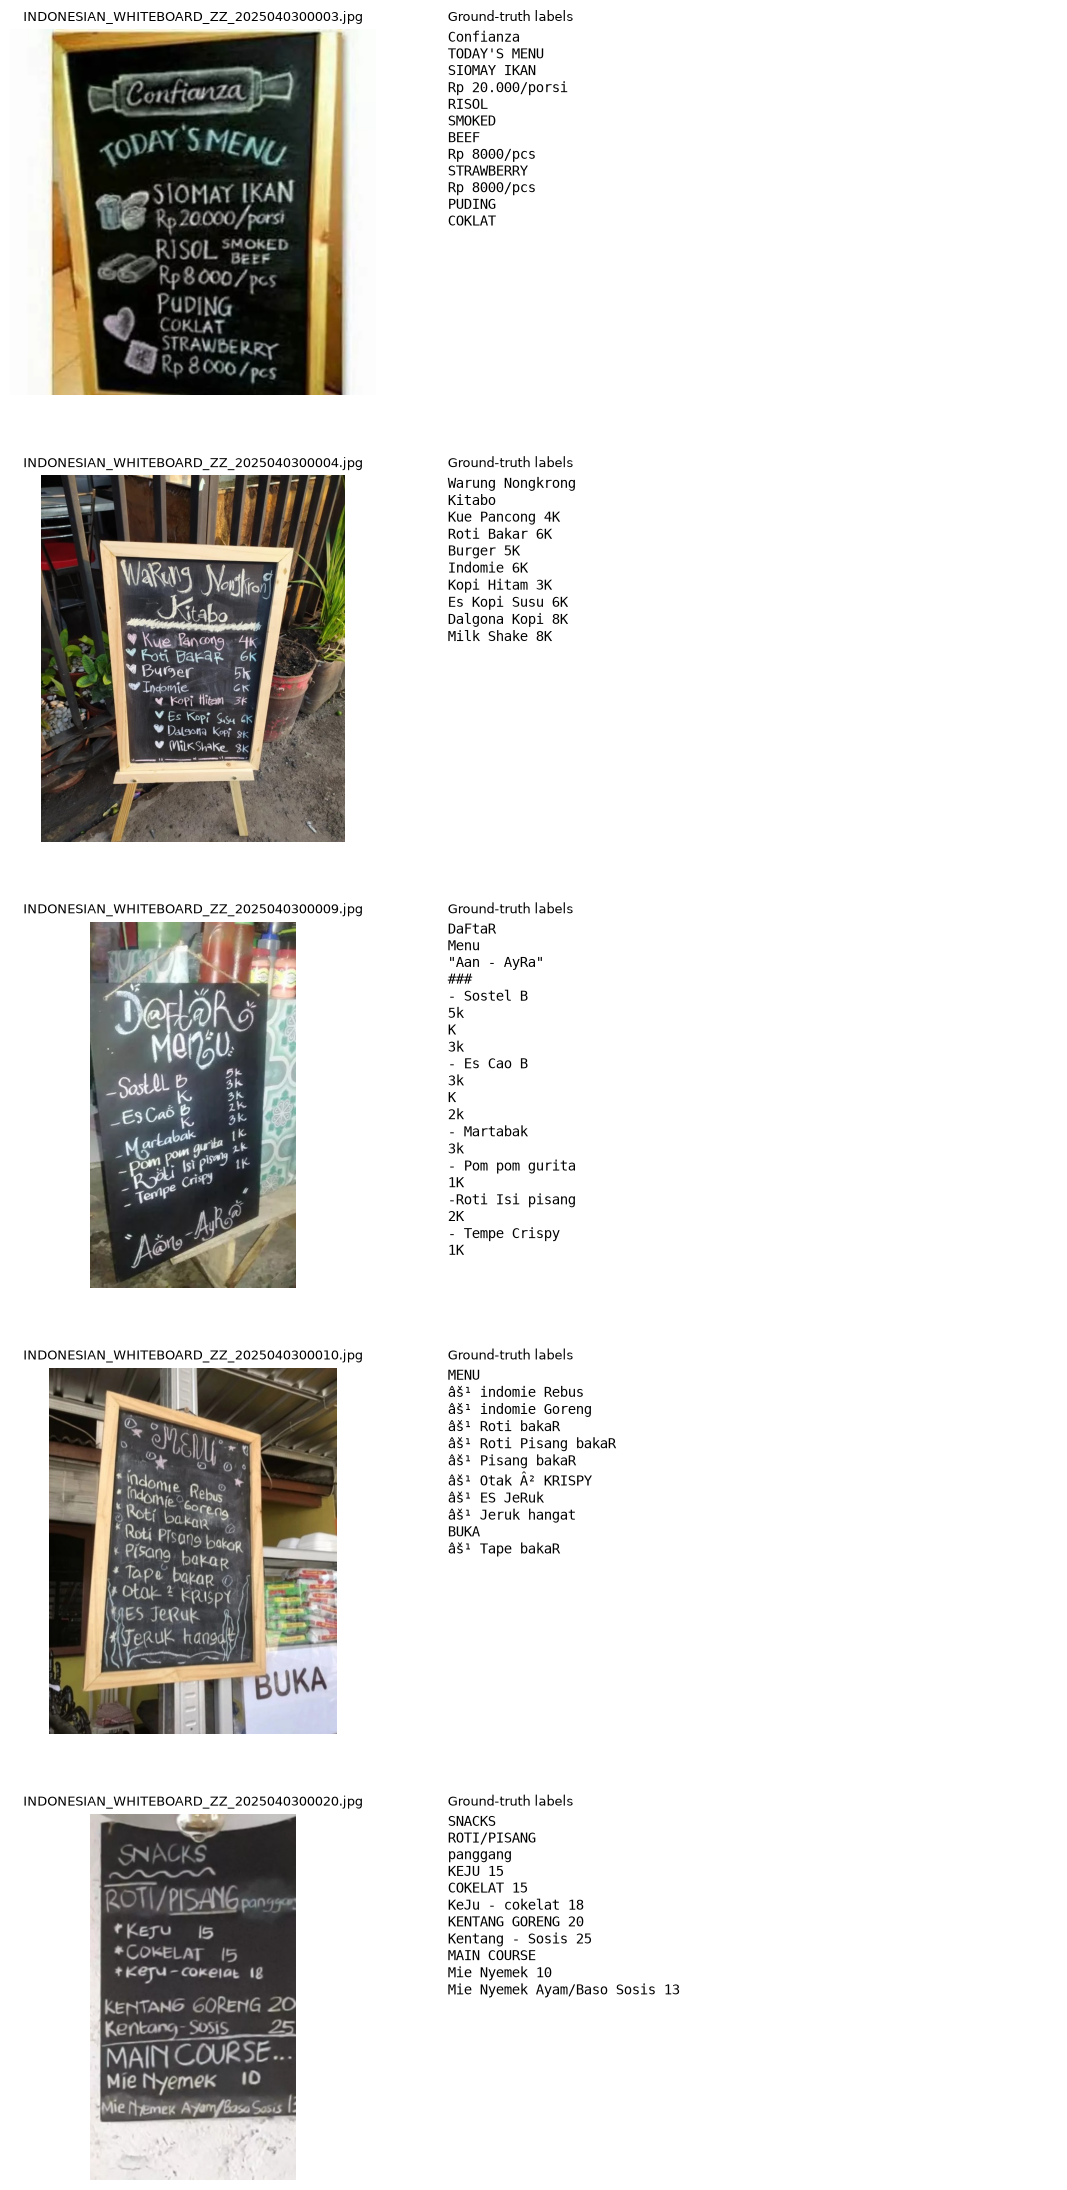

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

def preview_samples(n=5):
    """Show the first `n` images side-by-side with their ground-truth labels."""
    subset = samples[:n]
    if not subset:
        print("No samples loaded — check DATA_DIR.")
        return
    fig, axes = plt.subplots(len(subset), 2, figsize=(12, 4.4 * len(subset)),
                             gridspec_kw={"width_ratios": [1, 1]})
    if len(subset) == 1:
        axes = axes.reshape(1, 2)
    for row, (img_path, ann_path) in enumerate(subset):
        img = Image.open(img_path).convert("RGB")
        axes[row, 0].imshow(img)
        axes[row, 0].set_title(img_path.name, fontsize=9)
        axes[row, 0].axis("off")

        gt = load_gt_text(ann_path)
        axes[row, 1].axis("off")
        axes[row, 1].set_title("Ground-truth labels", fontsize=9, loc="left")
        axes[row, 1].text(0.0, 1.0, gt, va="top", ha="left",
                          fontsize=10, family="monospace",
                          transform=axes[row, 1].transAxes)
    plt.tight_layout()
    plt.show()

# Preview a few images with their ground-truth transcription
preview_samples(n=5)

## 5. Prompt & helpers

All four providers get the **same image + same prompt**, asking for a plain-text transcription.
Latency is wall-clock around the call; token counts come straight from each API's `usage` object.

In [8]:
PROMPT = (
    "This is a photo of a handwritten Indonesian food-stall menu on a whiteboard/blackboard. "
    "Transcribe ALL the text you can read, line by line, preserving the reading order (top to "
    "bottom). Keep prices and numbers exactly as written. "
    "Output ONLY the transcribed text — no commentary, no explanations, no markdown fences."
)


def encode_image_b64(path: Path) -> str:
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def _media_type(path: Path) -> str:
    return "image/png" if path.suffix.lower() == ".png" else "image/jpeg"


def clean_output(text: str) -> str:
    """Strip stray markdown fences a model might wrap around the transcription."""
    t = (text or "").strip()
    if t.startswith("```"):
        t = t.strip("`")
        t = re.sub(r"^[a-zA-Z]+\n", "", t, count=1)
    return t.strip()

## 5a–d. Per-provider vision calls
OpenAI, xAI and DeepSeek use the OpenAI-compatible `image_url` block; Claude uses the Anthropic `image` block.

In [9]:
# 5a. OpenAI
def call_openai(image_path: Path, model: str):
    from openai import OpenAI
    client = OpenAI(api_key=OPENAI_API_KEY)
    b64 = encode_image_b64(image_path)
    t0 = time.perf_counter()
    resp = client.chat.completions.create(
        model=model, max_tokens=1024,
        messages=[{"role": "user", "content": [
            {"type": "text", "text": PROMPT},
            {"type": "image_url", "image_url": {"url": f"data:{_media_type(image_path)};base64,{b64}"}},
        ]}],
    )
    lat = time.perf_counter() - t0
    return resp.choices[0].message.content, lat, resp.usage.prompt_tokens, resp.usage.completion_tokens


# 5b. Claude (Anthropic)
def call_claude(image_path: Path, model: str):
    import anthropic
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    b64 = encode_image_b64(image_path)
    t0 = time.perf_counter()
    resp = client.messages.create(
        model=model, max_tokens=1024,
        messages=[{"role": "user", "content": [
            {"type": "image", "source": {"type": "base64", "media_type": _media_type(image_path), "data": b64}},
            {"type": "text", "text": PROMPT},
        ]}],
    )
    lat = time.perf_counter() - t0
    text = "".join(b.text for b in resp.content if getattr(b, "type", None) == "text")
    return text, lat, resp.usage.input_tokens, resp.usage.output_tokens


# 5c. xAI / Grok (OpenAI-compatible)
def call_xai(image_path: Path, model: str):
    from openai import OpenAI
    client = OpenAI(api_key=XAI_API_KEY, base_url="https://api.x.ai/v1")
    b64 = encode_image_b64(image_path)
    t0 = time.perf_counter()
    resp = client.chat.completions.create(
        model=model, max_tokens=1024,
        messages=[{"role": "user", "content": [
            {"type": "text", "text": PROMPT},
            {"type": "image_url", "image_url": {"url": f"data:{_media_type(image_path)};base64,{b64}"}},
        ]}],
    )
    lat = time.perf_counter() - t0
    return resp.choices[0].message.content, lat, resp.usage.prompt_tokens, resp.usage.completion_tokens


# 5d. DeepSeek (OpenAI-compatible) — only works if MODELS["deepseek"] is a vision model
def call_deepseek(image_path: Path, model: str):
    from openai import OpenAI
    client = OpenAI(api_key=DEEPSEEK_API_KEY, base_url="https://api.deepseek.com")
    b64 = encode_image_b64(image_path)
    t0 = time.perf_counter()
    resp = client.chat.completions.create(
        model=model, max_tokens=1024,
        messages=[{"role": "user", "content": [
            {"type": "text", "text": PROMPT},
            {"type": "image_url", "image_url": {"url": f"data:{_media_type(image_path)};base64,{b64}"}},
        ]}],
    )
    lat = time.perf_counter() - t0
    return resp.choices[0].message.content, lat, resp.usage.prompt_tokens, resp.usage.completion_tokens


PROVIDER_FUNCS = {
    "openai":   call_openai,
    "claude":   call_claude,
    "xai":      call_xai,
    "deepseek": call_deepseek,
}
print("API helpers ready.")

API helpers ready.


## 6. OCR metrics — CER & WER

We normalise both reference and hypothesis (lowercase, collapse whitespace) before scoring so the
error rates reflect real transcription mistakes rather than formatting noise.

- **CER** = character-level edit distance / #reference chars (↓ better)
- **WER** = word-level edit distance / #reference words (↓ better)
- **char / word accuracy** = `max(0, 1 - CER/WER)`


In [11]:
%pip install jiwer -y

Note: you may need to restart the kernel to use updated packages.



[optparse.groups]Usage:[/]   
  d:\Miniconda\miniconda3\envs\api-env\python.exe -m pip install \[options] <requirement specifier> \[package-index-options] ...
  d:\Miniconda\miniconda3\envs\api-env\python.exe -m pip install \[options] -r <requirements file> \[package-index-options] ...
  d:\Miniconda\miniconda3\envs\api-env\python.exe -m pip install \[options] [-e] <vcs project url> ...
  d:\Miniconda\miniconda3\envs\api-env\python.exe -m pip install \[options] [-e] <local project path> ...
  d:\Miniconda\miniconda3\envs\api-env\python.exe -m pip install \[options] <archive url/path> ...

no such option: -y


In [12]:
import jiwer

def normalize_text(t: str) -> str:
    t = (t or "").lower()
    t = re.sub(r"\s+", " ", t).strip()
    return t

def score_ocr(reference: str, hypothesis: str) -> dict:
    ref = normalize_text(reference)
    hyp = normalize_text(hypothesis)
    if not ref:
        return {"cer": None, "wer": None, "char_acc": None, "word_acc": None, "exact": None}
    cer = jiwer.cer(ref, hyp)
    wer = jiwer.wer(ref, hyp)
    return {
        "cer": cer,
        "wer": wer,
        "char_acc": max(0.0, 1.0 - cer),
        "word_acc": max(0.0, 1.0 - wer),
        "exact": float(ref == hyp),
    }

## 7. Run the benchmark
Every image → every active provider. Errors are logged, not fatal. **This calls paid APIs.**

In [13]:
import traceback

rows = []
for img_path, ann_path in tqdm(samples, desc="images"):
    gt_text = load_gt_text(ann_path)

    for provider, model in MODELS.items():
        if model is None:
            continue
        if not API_KEYS.get(provider):
            print(f"Skipping {provider}: no API key set")
            continue
        try:
            raw, latency, ptoks, ctoks = PROVIDER_FUNCS[provider](img_path, model)
        except Exception as e:
            print(f"{provider} failed on {img_path.name}: {e}")
            traceback.print_exc()
            continue

        pred = clean_output(raw)
        m = score_ocr(gt_text, pred)
        price = PRICING_PER_1M[provider]
        cost = (ptoks / 1e6) * price["input"] + (ctoks / 1e6) * price["output"]

        rows.append({
            "image":       img_path.name,
            "provider":    provider,
            "model":       model,
            "gt_text":     gt_text,
            "prediction":  pred,
            "latency_s":   latency,
            "prompt_tokens":     ptoks,
            "completion_tokens": ctoks,
            "total_tokens":      ptoks + ctoks,
            "cost_usd":    cost,
            **m,
        })

df = pd.DataFrame(rows)
df.to_csv("result/ocr_benchmark_raw.csv", index=False)
print(f"\nCollected {len(df)} results.")
df[["image", "provider", "cer", "wer", "latency_s", "total_tokens", "cost_usd"]].head(12)

images:   0%|          | 0/5 [00:00<?, ?it/s]


Collected 15 results.


,image,provider,cer,wer,latency_s,total_tokens,cost_usd
0,INDONESIAN_WHITEBOARD_ZZ_2025040300003.jpg,openai,0.264957,0.411765,2.618508,898,0.002687
1,INDONESIAN_WHITEBOARD_ZZ_2025040300003.jpg,claude,0.256410,0.352941,3.399618,838,0.003438
2,INDONESIAN_WHITEBOARD_ZZ_2025040300003.jpg,xai,0.256410,0.352941,10.090506,846,0.003222
3,INDONESIAN_WHITEBOARD_ZZ_2025040300004.jpg,openai,0.007519,0.076923,1.761293,908,0.002788
4,INDONESIAN_WHITEBOARD_ZZ_2025040300004.jpg,claude,0.127820,0.346154,4.013748,1091,0.004653
5,INDONESIAN_WHITEBOARD_ZZ_2025040300004.jpg,xai,0.127820,0.346154,10.380708,1035,0.004053
6,INDONESIAN_WHITEBOARD_ZZ_2025040300009.jpg,openai,0.297101,0.485714,2.641578,1267,0.003827
7,INDONESIAN_WHITEBOARD_ZZ_2025040300009.jpg,claude,0.224638,0.285714,4.654081,1375,0.005253
8,INDONESIAN_WHITEBOARD_ZZ_2025040300009.jpg,xai,0.260870,0.485714,13.883255,1261,0.004755
9,INDONESIAN_WHITEBOARD_ZZ_2025040300010.jpg,openai,0.347561,0.516129,1.296786,896,0.002667


## 8. Summary — quality, latency, tokens, cost per provider

In [14]:
summary = df.groupby("provider").agg(
    mean_cer        = ("cer",       "mean"),
    mean_wer        = ("wer",       "mean"),
    mean_char_acc   = ("char_acc",  "mean"),
    mean_word_acc   = ("word_acc",  "mean"),
    exact_match     = ("exact",     "mean"),
    mean_latency_s  = ("latency_s", "mean"),
    p95_latency_s   = ("latency_s", lambda s: s.quantile(0.95)),
    mean_prompt_tok = ("prompt_tokens",     "mean"),
    mean_output_tok = ("completion_tokens", "mean"),
    total_tokens    = ("total_tokens",      "sum"),
    total_cost_usd  = ("cost_usd",          "sum"),
    avg_cost_usd    = ("cost_usd",          "mean"),
    n_images        = ("image",             "count"),
).round(5)

summary.to_csv("result/ocr_benchmark_summary.csv")
summary

,mean_cer,mean_wer,mean_char_acc,mean_word_acc,exact_match,mean_latency_s,p95_latency_s,mean_prompt_tok,mean_output_tok,total_tokens,total_cost_usd,avg_cost_usd,n_images
provider,,,,,,,,,,,,,
claude,0.20939,0.37945,0.79061,0.62055,0.0,4.54579,6.62877,1048.4,93.0,5707,0.02270,0.00454,5
openai,0.19617,0.36239,0.80383,0.63761,0.0,2.13347,2.63696,975.0,69.6,5223,0.01567,0.00313,5
xai,0.21127,0.37590,0.78873,0.62410,0.0,11.22839,13.72458,1011.0,70.0,5405,0.02042,0.00408,5


## 9. Charts

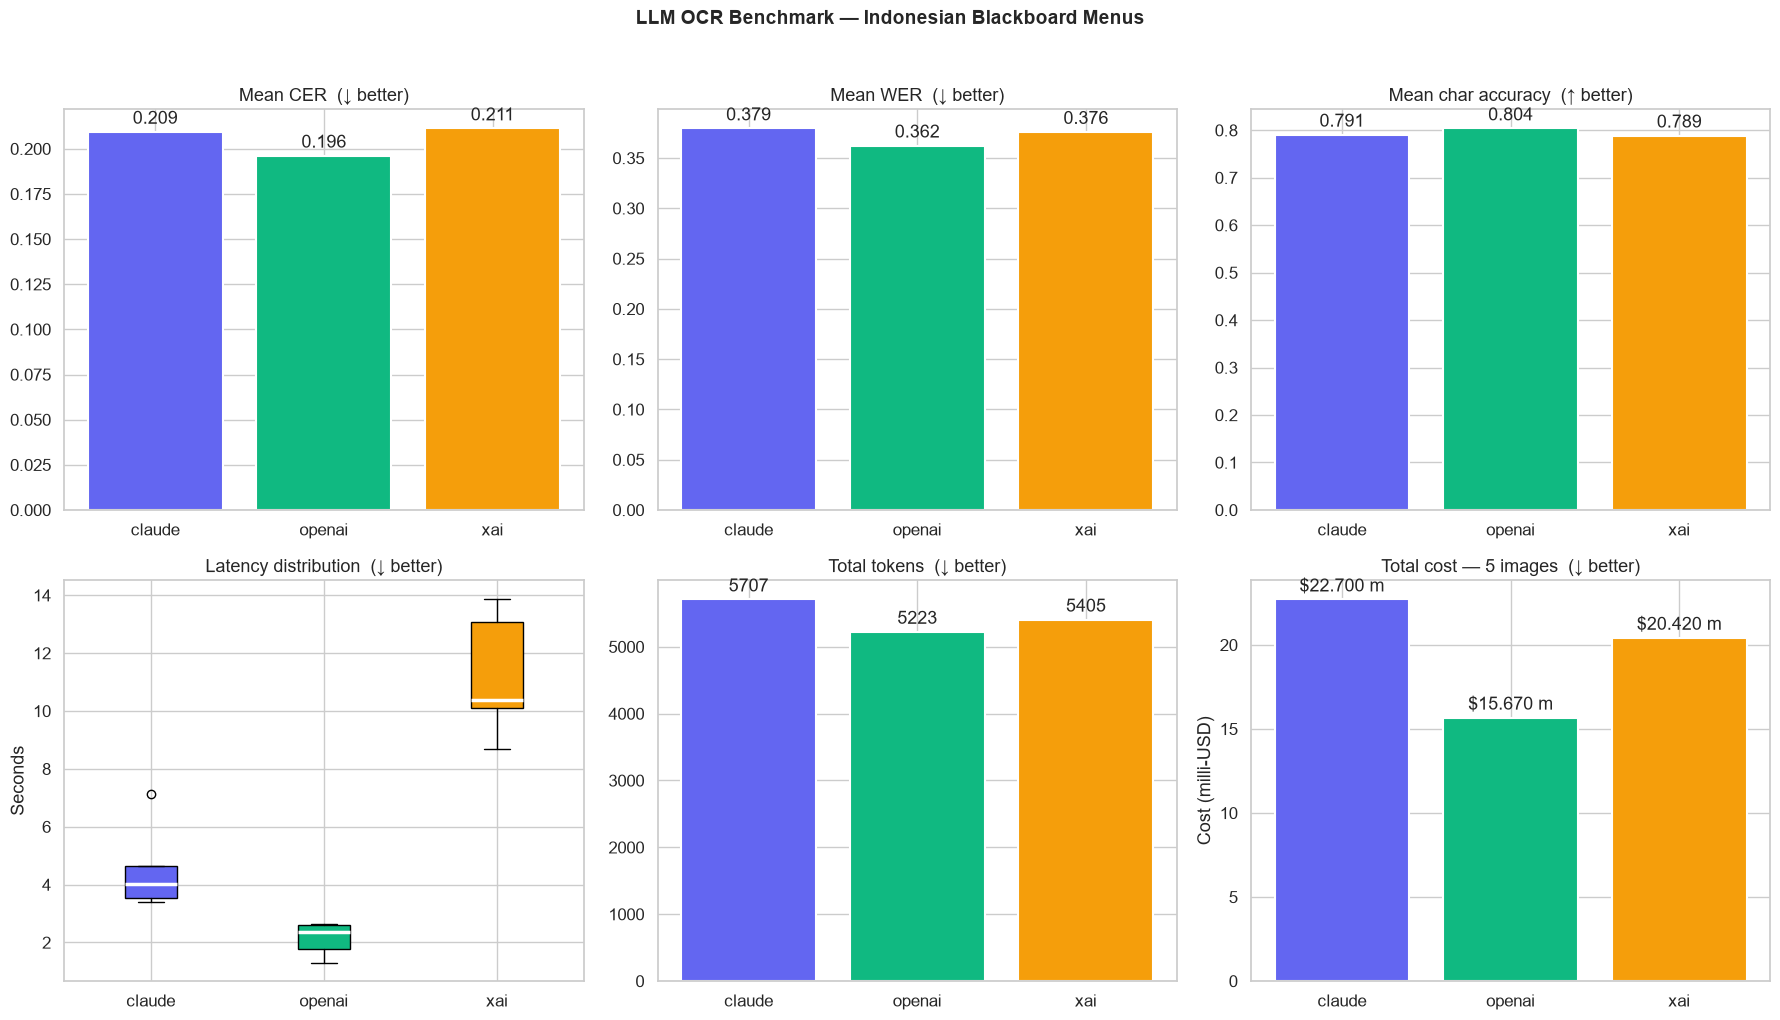

In [16]:
PALETTE     = {"claude": "#6366f1", "openai": "#10b981", "xai": "#f59e0b", "deepseek": "#ef4444"}
MODEL_ORDER = [m for m in ["claude", "openai", "xai", "deepseek"] if m in summary.index]
COLORS      = [PALETTE[m] for m in MODEL_ORDER]

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("LLM OCR Benchmark — Indonesian Blackboard Menus", fontsize=14, fontweight="bold", y=1.02)

def _bar(ax, col, title, fmt, lower_better):
    vals = [summary.loc[m, col] for m in MODEL_ORDER]
    b = ax.bar(MODEL_ORDER, vals, color=COLORS, edgecolor="white", linewidth=1.5)
    ax.bar_label(b, fmt=fmt, padding=3)
    ax.set_title(title + ("  (↓ better)" if lower_better else "  (↑ better)"))

_bar(axes[0, 0], "mean_cer",       "Mean CER",              "%.3f", True)
_bar(axes[0, 1], "mean_wer",       "Mean WER",              "%.3f", True)
_bar(axes[0, 2], "mean_char_acc",  "Mean char accuracy",    "%.3f", False)

# latency distribution box
ax = axes[1, 0]
data_lat = [df[df["model"] == MODELS[m]]["latency_s"].values for m in MODEL_ORDER]
# bp = ax.boxplot(data_lat, labels=MODEL_ORDER, patch_artist=True,
#                 medianprops=dict(color="white", linewidth=2.5))
bp = ax.boxplot(data_lat, tick_labels=MODEL_ORDER, patch_artist=True,
                medianprops=dict(color="white", linewidth=2.5))
for patch, c in zip(bp["boxes"], COLORS):
    patch.set_facecolor(c)
ax.set_title("Latency distribution  (↓ better)"); ax.set_ylabel("Seconds")

_bar(axes[1, 1], "total_tokens",   "Total tokens",          "%.0f", True)

ax = axes[1, 2]
vals = [summary.loc[m, "total_cost_usd"] * 1000 for m in MODEL_ORDER]
b = ax.bar(MODEL_ORDER, vals, color=COLORS, edgecolor="white", linewidth=1.5)
ax.bar_label(b, fmt="$%.3f m", padding=3)
ax.set_title(f"Total cost — {len(samples)} images  (↓ better)"); ax.set_ylabel("Cost (milli-USD)")

plt.tight_layout()
plt.savefig("fig/ocr_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Accuracy vs cost scatter

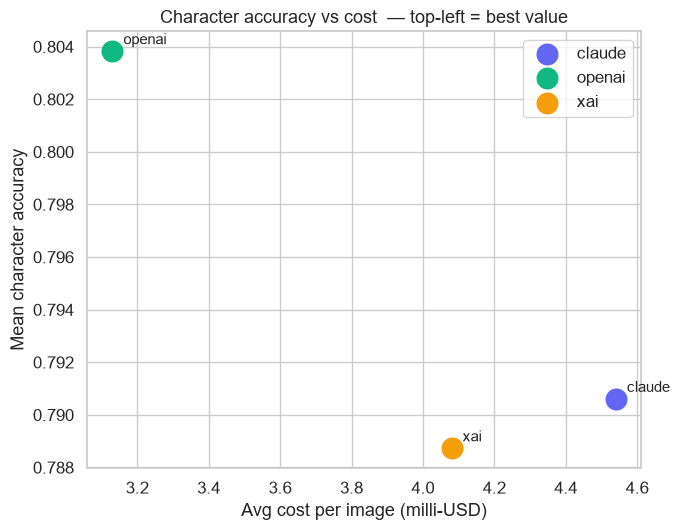

In [17]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for m in MODEL_ORDER:
    x = summary.loc[m, "avg_cost_usd"] * 1000
    y = summary.loc[m, "mean_char_acc"]
    ax.scatter(x, y, s=220, color=PALETTE[m], zorder=5, label=m)
    ax.annotate(m, (x, y), textcoords="offset points", xytext=(8, 5), fontsize=11)
ax.set_xlabel("Avg cost per image (milli-USD)")
ax.set_ylabel("Mean character accuracy")
ax.set_title("Character accuracy vs cost  — top-left = best value")
ax.legend()
plt.tight_layout()
plt.savefig("fig/ocr_cost_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Side-by-side transcription examples


IMAGE: INDONESIAN_WHITEBOARD_ZZ_2025040300003.jpg


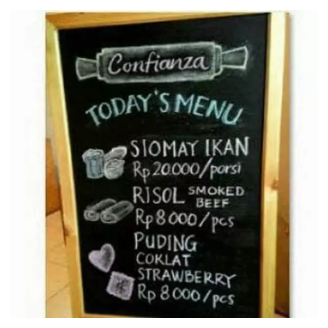

GROUND TRUTH:
Confianza
TODAY'S MENU
SIOMAY IKAN
Rp 20.000/porsi
RISOL
SMOKED
BEEF
Rp 8000/pcs
STRAWBERRY
Rp 8000/pcs
PUDING
COKLAT

  [  openai] CER=0.265 WER=0.412 lat=2.62s tokens=898 cost=$2.6875m
    Confianza
    TODAY'S MENU
    SIOMAY IKAN
    Rp. 20.000/porsi
    RISOL SMOKED BEEF
    Rp 8.000/pcs
    PUDING
    COKLAT
    STRAWBERRY
    Rp 8.000/pcs

  [  claude] CER=0.256 WER=0.353 lat=3.40s tokens=838 cost=$3.4380m
    Confianza
    TODAY'S MENU
    SIOMAY IKAN
    Rp 20.000/porsi
    RISOL SMOKED
    BEEF
    Rp 8.000/pcs
    PUDING
    COKLAT
    STRAWBERRY
    Rp 8.000/pcs

  [     xai] CER=0.256 WER=0.353 lat=10.09s tokens=846 cost=$3.2220m
    Confianza
    TODAY'S MENU
    SIOMAY IKAN
    Rp 20.000/porsi
    RISOL SMOKED BEEF
    Rp 8.000/pcs
    PUDING
    COKLAT
    STRAWBERRY
    Rp 8.000/pcs

IMAGE: INDONESIAN_WHITEBOARD_ZZ_2025040300004.jpg


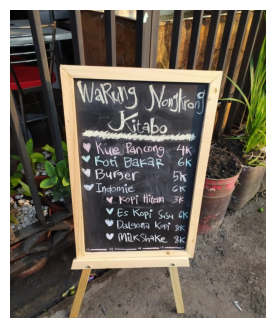

GROUND TRUTH:
Warung Nongkrong
Kitabo
Kue Pancong 4K
Roti Bakar 6K
Burger 5K
Indomie 6K
Kopi Hitam 3K
Es Kopi Susu 6K
Dalgona Kopi 8K
Milk Shake 8K

  [  openai] CER=0.008 WER=0.077 lat=1.76s tokens=908 cost=$2.7875m
    Warung Nongkrong  
    Kitabo  
    Kue Pancong 4k  
    Roti Bakar 6k  
    Burger 5k  
    Indomie 6k  
    Kopi Hitam 3k  
    Es Kopi Susu 6k  
    Dalgona Kopi 8k  
    Milkshake 8k

  [  claude] CER=0.128 WER=0.346 lat=4.01s tokens=1091 cost=$4.6530m
    Warung Nongkrong
    Kitabo
    ♥ Kue Pancong 4k
    ♥ Roti Bakar 6k
    ♥ Burger 5k
    ♥ Indomie 6k
    ♥ Kopi Hitam 3k
    ♥ Es Kopi Susu 6k
    ♥ Dalgona Kopi 8k
    ♥ MilkShake 8k

  [     xai] CER=0.128 WER=0.346 lat=10.38s tokens=1035 cost=$4.0530m
    WaRung Nongkrong
    Kitabo
    ♡ Kue Pancong 4K
    ♡ Roti Bakar 6K
    ♡ Burger 5K
    ♡ Indomie 6K
      ♡ Kopi Hitam 3K
    ♡ Es Kopi Susu 6K
    ♡ Dalgona Kopi 8K
    ♡ Milkshake 8K

IMAGE: INDONESIAN_WHITEBOARD_ZZ_2025040300009.jpg


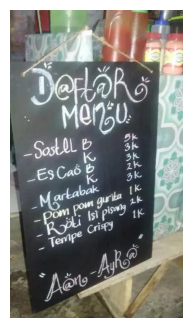

GROUND TRUTH:
DaFtaR
Menu
"Aan - AyRa"
###
- Sostel B
5k
K
3k
- Es Cao B
3k
K
2k
- Martabak
3k
- Pom pom gurita
1K
-Roti Isi pisang
2K
- Tempe Crispy
1K

  [  openai] CER=0.297 WER=0.486 lat=2.64s tokens=1267 cost=$3.8275m
    DaftAr MenÜ
    
    - Sostll B        5k
                             3k
    - Es Caö B      3k
                             2k 
                             3k
    - Martabak     1k
    - Pom pom gurita  2k
    - RötI Isi pisang      2k
    - Tempe Crispy    1k
    
    "AäN - AyRa"

  [  claude] CER=0.225 WER=0.286 lat=4.65s tokens=1375 cost=$5.2530m
    Daftar
    Menu:
    
    - Sostel B          5k
             K          3k
    - Es Cao B          3k
             K          2k
    - Martabak          3k
    - Pom pom gurita    1k
    - Roti Isi pisang   2k
    - Tempe Crispy      1k
    
    "Aan - Ayra"

  [     xai] CER=0.261 WER=0.486 lat=13.88s tokens=1261 cost=$4.7550m
    DAFTAR MENU
    - Sostel B K     5k
                     3k
    - Es Cao B K  

In [18]:
n_show = min(3, len(samples))
for img_path, ann_path in samples[:n_show]:
    sub = df[df["image"] == img_path.name]
    if sub.empty:
        continue
    print(f"\n{'='*80}\nIMAGE: {img_path.name}")
    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(img_path).convert("RGB")); plt.axis("off"); plt.show()
    print("GROUND TRUTH:\n" + sub.iloc[0]["gt_text"])
    for _, r in sub.iterrows():
        print(f"\n  [{r['provider']:>8}] CER={r['cer']:.3f} WER={r['wer']:.3f} "
              f"lat={r['latency_s']:.2f}s tokens={r['total_tokens']} cost=${r['cost_usd']*1000:.4f}m")
        print("    " + r["prediction"].replace("\n", "\n    "))

## 12. Final leaderboard

In [19]:
leaderboard = summary[[
    "mean_cer", "mean_wer", "mean_char_acc", "exact_match",
    "mean_latency_s", "p95_latency_s",
    "mean_prompt_tok", "mean_output_tok", "total_tokens",
    "avg_cost_usd", "total_cost_usd",
]].copy()
leaderboard["avg_cost_m"]   = (leaderboard.pop("avg_cost_usd")   * 1000).round(4)
leaderboard["total_cost_m"] = (leaderboard.pop("total_cost_usd") * 1000).round(4)
leaderboard.columns = [
    "CER", "WER", "CharAcc", "ExactMatch",
    "Avg Lat(s)", "P95 Lat(s)",
    "Avg InTok", "Avg OutTok", "Total Tok",
    "Avg Cost(m$)", "Total Cost(m$)",
]
leaderboard.sort_values("CER", ascending=True, inplace=True)

display(
    leaderboard.style
    .background_gradient(subset=["CER", "WER"],                 cmap="Reds_r")
    .background_gradient(subset=["CharAcc", "ExactMatch"],      cmap="Greens")
    .background_gradient(subset=["Avg Lat(s)", "P95 Lat(s)"],   cmap="Reds_r")
    .background_gradient(subset=["Total Cost(m$)"],             cmap="Oranges_r")
    .format(precision=3)
)

,CER,WER,CharAcc,ExactMatch,Avg Lat(s),P95 Lat(s),Avg InTok,Avg OutTok,Total Tok,Avg Cost(m$),Total Cost(m$)
provider,,,,,,,,,,,
openai,0.196,0.362,0.804,0.000,2.133,2.637,975.000,69.600,5223,3.130,15.670
claude,0.209,0.379,0.791,0.000,4.546,6.629,1048.400,93.000,5707,4.540,22.700
xai,0.211,0.376,0.789,0.000,11.228,13.725,1011.000,70.000,5405,4.080,20.420


---
### Metric guide

| Metric | Direction | Notes |
|--------|-----------|-------|
| **CER** | ↓ lower is better | Character error rate = char edit distance / #reference chars |
| **WER** | ↓ lower is better | Word error rate = word edit distance / #reference words |
| **Char / Word accuracy** | ↑ higher is better | `max(0, 1 − CER/WER)` |
| **Exact match** | ↑ higher is better | Fraction of images transcribed identically (after normalisation) |
| **Latency** | ↓ lower is better | Wall-clock time per API call |
| **Tokens** | ↓ lower is better | Image tokens are included in each provider's reported prompt tokens |
| **Cost** | ↓ lower is better | Derived from official per-token pricing |

**Caveats:** ground truth is the LabelMe region labels joined in annotation order, which only
approximates true reading order — reordered-but-correct transcriptions can still incur WER. Handle
with care and inspect the side-by-side examples in section 11.


# Tugas

Cobalah evaluasi performa pilihan model vision Anthropic, OpenAI, xAI (dan DeepSeek jika Anda punya
akses ke model vision-nya) pada dataset blackboard di atas. Beberapa ide:
- Ganti `MODELS` dengan tier lain (mis. `gpt-4o-mini`, `claude-haiku-4-5`, `grok-4.1-fast`) dan
  bandingkan trade-off biaya vs CER/WER.
- Ubah `PROMPT` (mis. minta output per baris, atau minta format tabel menu) dan lihat pengaruhnya
  pada CER/WER dan jumlah token.
- Tambahkan pra-pemrosesan gambar (resize / kontras) dan ukur dampaknya terhadap akurasi.